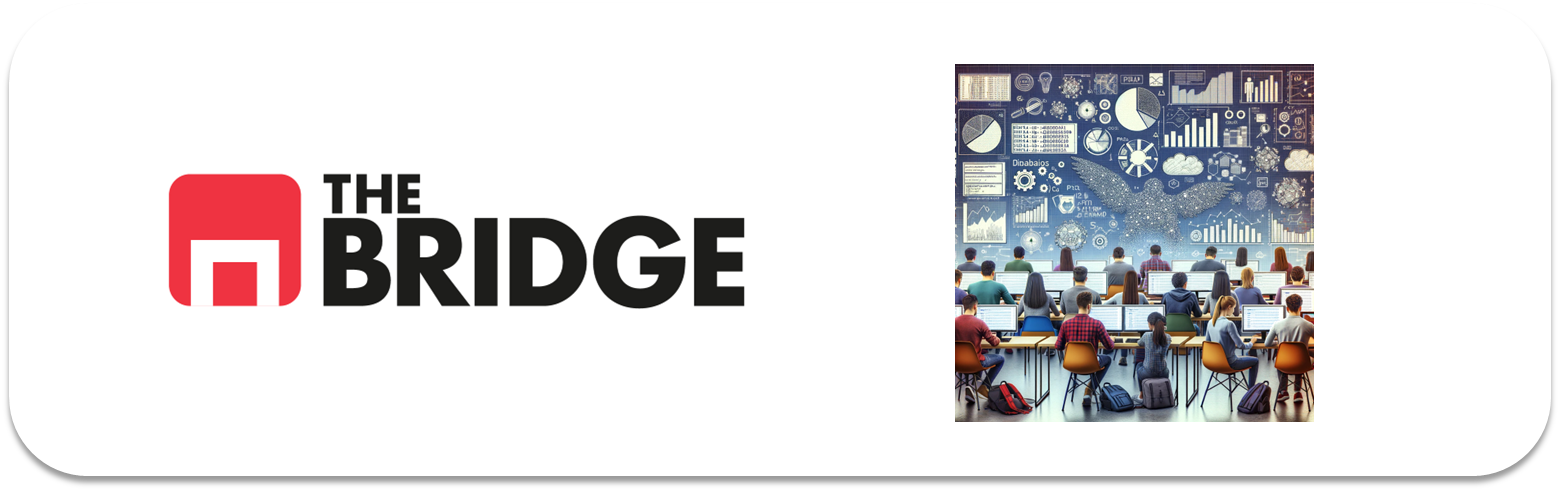

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



## Cargar el dataset

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import linear_model, metrics, model_selection
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge, Lasso
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
living_data = pd.read_csv('.\\data\\hard_to_find\\obligatoria_hard.csv', delimiter="|")
living_data.sample(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
388,14.3337,0.0,18.10,0.0,0.700,4.880,100.0,1.5895,24.0,666.0,20.2,30.62,10.2
88,0.0566,0.0,3.41,0.0,0.489,7.007,86.3,3.4217,2.0,270.0,17.8,5.50,23.6
303,0.1000,34.0,6.09,0.0,0.433,6.982,17.7,5.4917,7.0,329.0,16.1,4.86,33.1
414,45.7461,0.0,18.10,0.0,0.693,4.519,100.0,1.6582,24.0,666.0,20.2,36.98,7.0
223,0.6147,0.0,6.20,0.0,0.507,6.618,80.8,3.2721,8.0,307.0,17.4,7.60,30.1


In [3]:
living_data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


## Evaluación de la variable target

Veamos la distribución de la variable target MEDV.

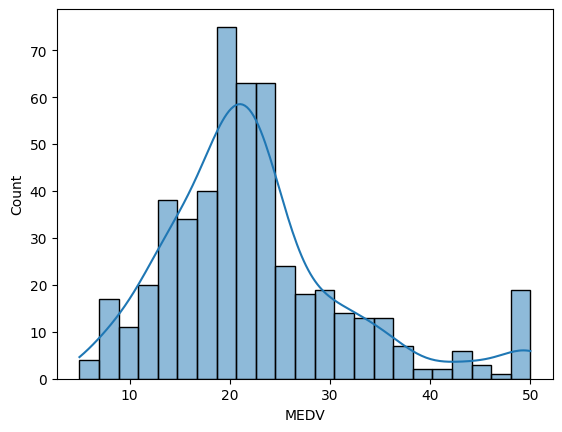

In [4]:
sns.histplot(living_data.MEDV, kde=True);


## Split train-test al 80-20%:

In [5]:
train_set, test_set = train_test_split(living_data, test_size=0.2, random_state=26)
target = "MEDV"
X_train = train_set.drop(target, axis=1)
y_train = train_set[target]
X_test = test_set.drop(target, axis=1)
y_test = test_set[target]

In [6]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape, sep="\n")

(404, 12)
(102, 12)
(404,)
(102,)


## Mini-EDA

La variable MEDV tiene una distribución asimétrica. Se puede transformar la variable por la raíz cuadrada para obtener una distribución más simétrica.

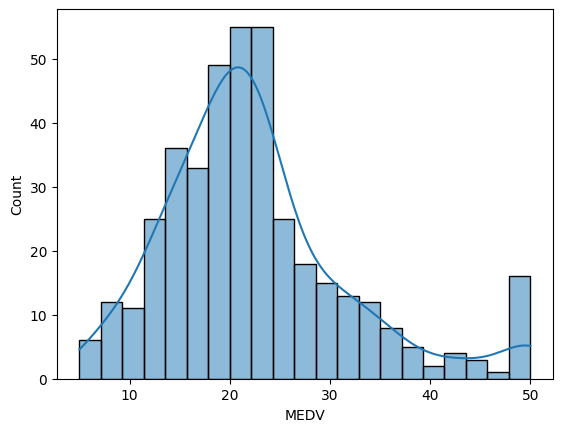

In [7]:
sns.histplot(train_set.MEDV, kde=True);

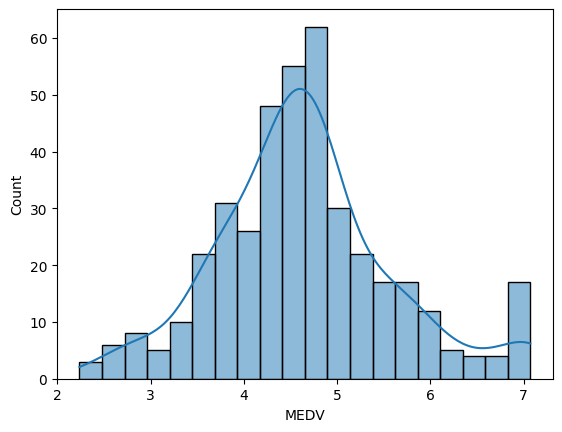

In [8]:
sns.histplot(train_set.MEDV.transform(lambda x: x**(1/2)), kde=True);

In [9]:
from matplotlib.colors import LinearSegmentedColormap
cmap_corr = LinearSegmentedColormap.from_list(
    "corr_suave",
    [
        (0.00, "#08306b"),   # azul oscuro
        (0.10, "#2166ac"),   # azul
        (0.20, "#d1e5f0"),   # azul claro
        (0.50, "#f7f7f7"),   # blanco
        (0.75, "#fddbc7"),   # rojo claro
        (1.00, "#b2182b")    # rojo oscuro
    ]
)

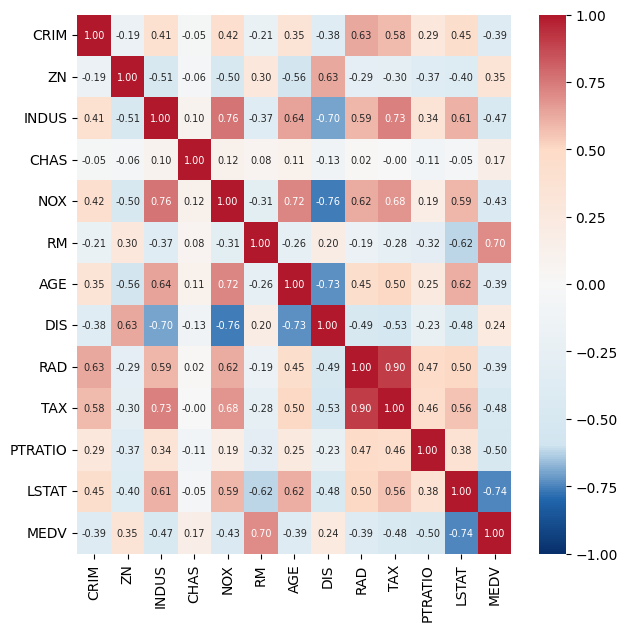

In [10]:
plt.figure(figsize=(7,7))
sns.heatmap(train_set.corr(), vmin=-1, vmax=1, annot=True, cmap=cmap_corr, fmt=".2f", annot_kws={"size": 7});

Hay muchas variables independientes con correlaciones altas entre ellas:
- La variable **INDUS** tiene correlaciones fuertes con las variables **NOX**, AGE, RAD, **TAX** y LSTAT 
- La variable **NOX** tiene también una correlación fuerte con **AGE** y **DIS** (negativa).
- Las variables **TAX** y **RAD** tienen una correlación muy fuerte de 0.9.

Las variables más correladas con la target son **RM** (0.7) y **LSTAT** (-0.7).
Las variable CHAS y DIS tienen una correlación despreciable con nuestra var. objetivo, por lo que no se tendrán en cuenta en la regresión.

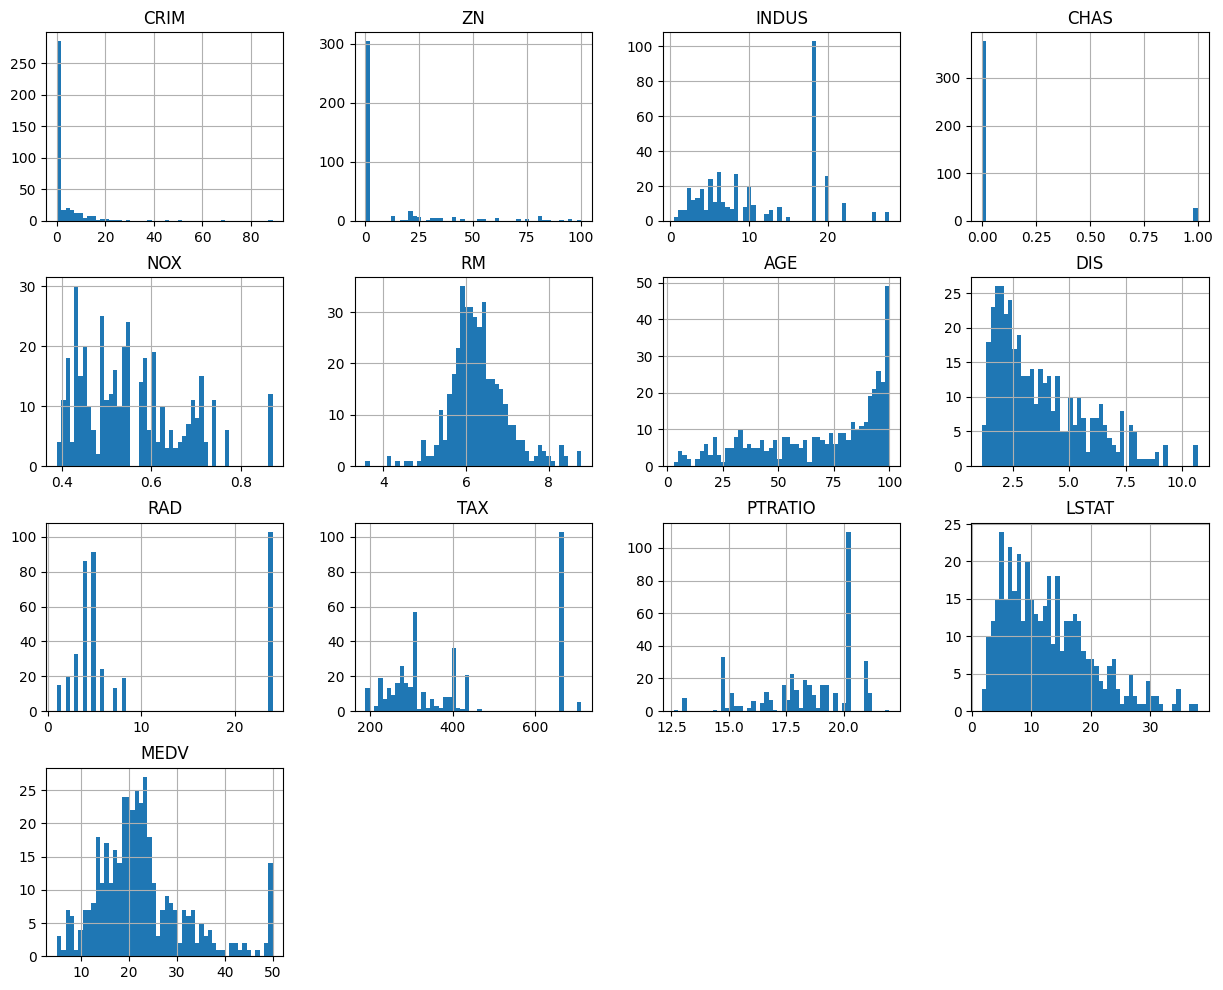

In [11]:
train_set.hist(bins=50, figsize=(15, 12))
plt.show()

Hay varias variables con distribuciones muy asimétricas y bimodales.

In [12]:
vars_asim = ["ZN", "CRIM", "CHAS", "RAD", "TAX", "PTRATIO"]
print(train_set[vars_asim].describe())

               ZN        CRIM        CHAS         RAD         TAX     PTRATIO
count  404.000000  404.000000  404.000000  404.000000  404.000000  404.000000
mean    10.399752    3.490754    0.066832    9.435644  407.606436   18.461386
std     22.243754    8.371929    0.250040    8.645102  167.983726    2.106964
min      0.000000    0.006320    0.000000    1.000000  188.000000   12.600000
25%      0.000000    0.079710    0.000000    4.000000  279.000000   17.400000
50%      0.000000    0.256510    0.000000    5.000000  330.000000   18.900000
75%      0.000000    3.497880    0.000000   24.000000  666.000000   20.200000
max    100.000000   88.976200    1.000000   24.000000  711.000000   22.000000


In [13]:
(train_set["ZN"] > 0).value_counts()

ZN
False    304
True     100
Name: count, dtype: int64

### FEATURES
Se seleccionan las siguientes variables como features para la regresión, evitando la inclusión de variables muy correlacionadas entre sí o con baja correlación con la variable objetivo **MEDV**:
- **RM**: número promedio de habitantes por vivienda.
- **LSTAT**: porcentaje de población de estatus socioeconómico bajo.
- **PTRATIO**: midiendo la influencia de la capacidad educativa de la zona.
- **CRIM**: como medidor de la tasa de criminalidad.
- **NOX**: como variable representativa de la presencia industrial.

Notablemente, se descartta la variable INDUS dada su alta correlación con muchas otras variables, entre las LSTAT y NOX.

## Tratamiento de variables

In [14]:
features = ["RM", "LSTAT", "PTRATIO", "CRIM", "NOX"]    # Todas las variables son numéricas

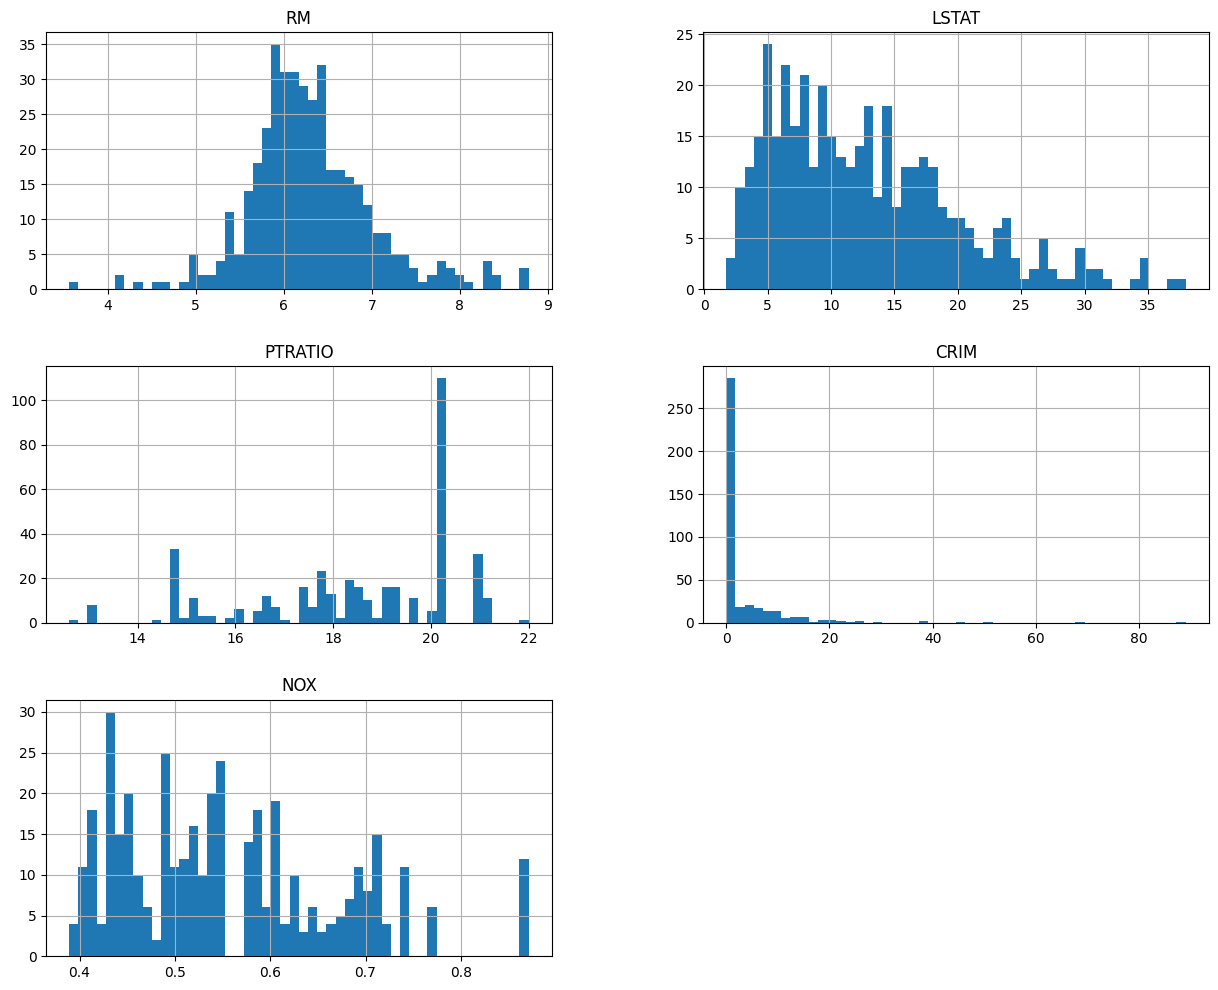

In [15]:
# Veamos de nuevo las distribuciones
train_set[features].hist(bins=50, figsize=(15, 12))
plt.show()

Las variables LSTAT, CRIM y NOX tiene distribuciones asimétricas positivas, mientras que la variable PTRATIO presenta asimetría negativa y una ligera bimodalidad.

La variable RM es relativamente simétrica.

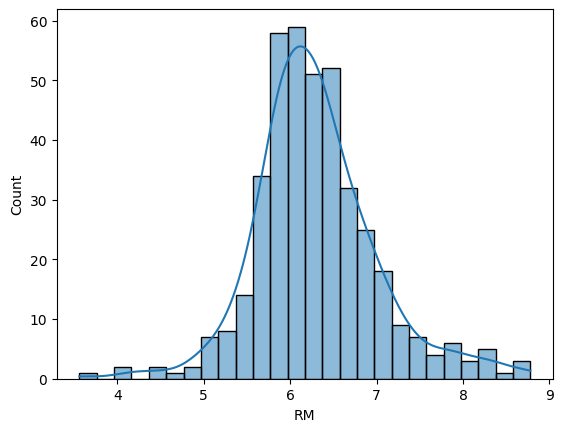

In [16]:
sns.histplot(train_set.RM, kde=True);

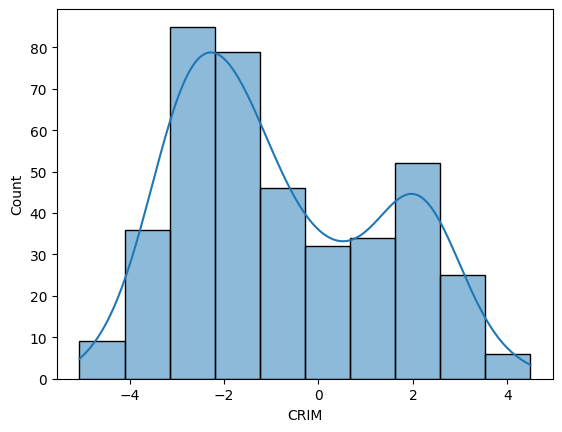

In [17]:
# Realizando una transformación logarítmica queda una distribución más uniforme, pero bimodal
sns.histplot(train_set.CRIM.transform(np.log), kde=True);

LSTAT tiene una asimetría menos pronunciada, por lo que la transformación logarítmica sólo invertiría esa simetría. Se utyiliza una transformación por raíz cúbica en su lugar.

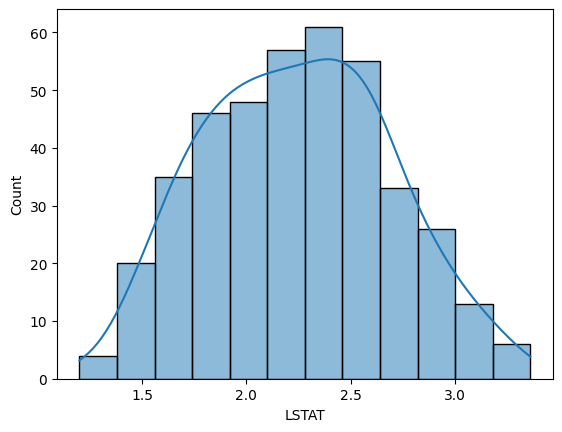

In [18]:
sns.histplot(train_set.LSTAT.transform(lambda x: x**(1/3)), kde=True);

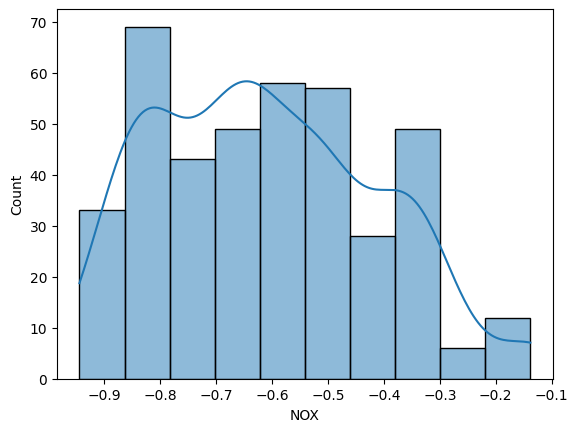

In [19]:
sns.histplot(train_set.NOX.transform(np.log), kde=True);

La variable PTRATIO presenta bimodalidad bajo cualquier transformación ordinaria, se elige la potencia cuarta porque produce el resultado con una kde más simétrica.

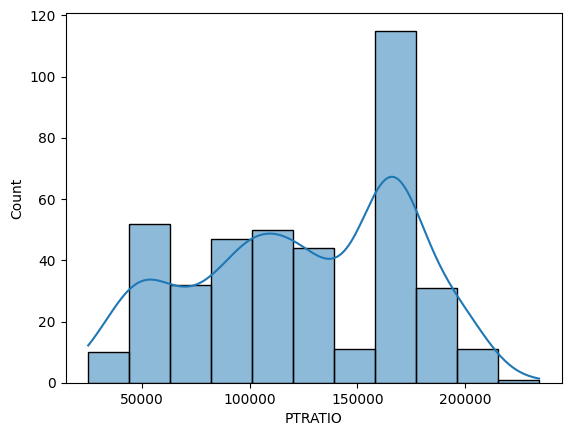

In [20]:
sns.histplot(train_set.PTRATIO.transform(lambda x: x**4), kde=True);

Nos importa la distribución estadística de los datos, así que es mejor estandarizar los datos:

In [21]:
y_train = train_set[target]

In [22]:
train_set["CRIM"] = train_set["CRIM"].transform(np.log)
train_set["NOX"] = train_set["NOX"].transform(np.log)
train_set["LSTAT"] = train_set.LSTAT.transform(lambda x: x**(1/3))
train_set["PTRATIO"] = train_set.PTRATIO.transform(lambda x: x**4)

In [23]:
std_scaler = StandardScaler()
std_scaler.fit(train_set[features])

train_set = pd.DataFrame(std_scaler.transform(train_set[features]), columns=features)

## Modelo de regresión y análisis de coeficientes

Antes de entrenar el modelo, tenemos que volver a crear las variables X e y que se indicaron en las instrucciones con los datos actualizados.

In [24]:
X_train = train_set[features]

In [25]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 2.51,-5.47,-1.73, 0.44, 0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['RM','LSTAT','PTRATIO','CRIM','NOX']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


Vemos que las variables que tenían correlación alta con MEDV, tienen pesos grandes en la regresión. Como scikit no da los p-valroes para los coeficientes de regresión , sólo podemos evaluar el grado de ajuste del modelo por medidas de errores.

In [26]:
print(lin_reg.coef_, lin_reg.feature_names_in_, sep="\n")

[ 2.51446359 -5.47133432 -1.72708717  0.44460398  0.1895902 ]
['RM' 'LSTAT' 'PTRATIO' 'CRIM' 'NOX']


## Evaluación del modelo
### Train Error

In [27]:
train_pred_lin = lin_reg.predict(X_train)
mse_lin_train = root_mean_squared_error(y_train, train_pred_lin)
print(mse_lin_train)

4.87999144229491


### Validation Error
Primero tenemos que transformar también las variables de test.

In [28]:
y_test = test_set[target]

In [29]:
test_set["CRIM"] = test_set["CRIM"].transform(np.log)
test_set["NOX"] = test_set["NOX"].transform(np.log)
test_set["LSTAT"] = test_set.LSTAT.transform(lambda x: x**(1/3))
test_set["PTRATIO"] = test_set.PTRATIO.transform(lambda x: x**4)

In [30]:
test_set = pd.DataFrame(std_scaler.transform(test_set[features]), columns=features)

In [31]:
X_test = test_set[features]


In [32]:
test_predict = lin_reg.predict(X_test)
mse_lin_test = root_mean_squared_error(y_test, test_predict)
print(mse_lin_test)

4.87748917203162


No hay mucha diferencia entre el error de entrenamiento yel de validación. De forma esperada, el error de entrenamiento es más bajo que el de validación.

In [33]:
print(f"Error de entrenamiento: {mse_lin_train:.4f}")
print(f"Error de validación: {mse_lin_test:.4f}")

Error de entrenamiento: 4.8800
Error de validación: 4.8775


## Regularización
Lo que más nos puede preocupar en este caso es una multicolinealidad entre variables independientes correlacionadas, a raíz de lo observado en la tabla de correlaciones. Vamos a probar tanto la regularización por Ridge como la regresión LASSO: 

In [37]:
print(f"Train MSE sin regularización: {mse_lin_train:.4f}")
print(f"Test MSE sin regularización: {mse_lin_test:.4f}", end="\n"*2)

for lmbda in [2, 4, 6, 8]:
    ridgeR = Ridge(alpha = lmbda) # alpha es lambda 
    ridgeR.fit(X_train, y_train)
    ridge_train_mse = metrics.root_mean_squared_error(y_train, ridgeR.predict(X_train))
    ridge_test_mse = metrics.root_mean_squared_error(y_test, ridgeR.predict(X_test))
    print(f"--- RIDGE PARA LAMBDA = {lmbda} ---")
    print(f"Train MSE: {ridge_train_mse:.4f}")
    print(f"Test MSE: {ridge_test_mse:.4f}")
    print(f"TRAIN: ridge - mse = {ridge_train_mse - mse_lin_train:.4f}")
    print(f"TEST: ridge - mse = {ridge_test_mse - mse_lin_test:.4f}", end="\n"*2)

Train MSE sin regularización: 4.8800
Test MSE sin regularización: 4.8775

--- RIDGE PARA LAMBDA = 2 ---
Train MSE: 4.8801
Test MSE: 4.8772
TRAIN: ridge - mse = 0.0001
TEST: ridge - mse = -0.0003

--- RIDGE PARA LAMBDA = 4 ---
Train MSE: 4.8806
Test MSE: 4.8772
TRAIN: ridge - mse = 0.0006
TEST: ridge - mse = -0.0003

--- RIDGE PARA LAMBDA = 6 ---
Train MSE: 4.8812
Test MSE: 4.8773
TRAIN: ridge - mse = 0.0013
TEST: ridge - mse = -0.0001

--- RIDGE PARA LAMBDA = 8 ---
Train MSE: 4.8822
Test MSE: 4.8777
TRAIN: ridge - mse = 0.0022
TEST: ridge - mse = 0.0002



La regularización por ridge no mejora mucho, para lambda = 2 tenemos el mejor resultado sobre el error de validación sin afectar al de entrenamiento, pero este es muy leve. Vamos a ver el LASSO:

In [40]:
print(f"Train MSE sin regularización: {mse_lin_train:.4f}")
print(f"Test MSE sin regularización: {mse_lin_test:.4f}", end="\n"*2)

for alph in [ 0.01, 0.02, 0.05, 0.06, 0.08]:
    lassoR = Lasso(alpha=alph)
    lassoR.fit(X_train, y_train)
    lasso_train_mse = metrics.root_mean_squared_error(y_train, lassoR.predict(X_train))
    lasso_test_mse = metrics.root_mean_squared_error(y_test, lassoR.predict(X_test))
    print(f"--- LASSO PARA ALPHA = {alph} ---")
    print(f"Train MSE: {lasso_train_mse:.4f}")
    print(f"Test MSE: {lasso_test_mse:.4f}")
    print(f"TRAIN: lasso - mse = {lasso_train_mse - mse_lin_train:.4f}")
    print(f"TEST: lasso - mse = {lasso_test_mse - mse_lin_test:.4f}", end="\n"*2)

Train MSE sin regularización: 4.8800
Test MSE sin regularización: 4.8775

--- LASSO PARA ALPHA = 0.01 ---
Train MSE: 4.8801
Test MSE: 4.8779
TRAIN: lasso - mse = 0.0001
TEST: lasso - mse = 0.0004

--- LASSO PARA ALPHA = 0.02 ---
Train MSE: 4.8803
Test MSE: 4.8785
TRAIN: lasso - mse = 0.0003
TEST: lasso - mse = 0.0010

--- LASSO PARA ALPHA = 0.05 ---
Train MSE: 4.8817
Test MSE: 4.8810
TRAIN: lasso - mse = 0.0017
TEST: lasso - mse = 0.0035

--- LASSO PARA ALPHA = 0.06 ---
Train MSE: 4.8825
Test MSE: 4.8821
TRAIN: lasso - mse = 0.0025
TEST: lasso - mse = 0.0046

--- LASSO PARA ALPHA = 0.08 ---
Train MSE: 4.8845
Test MSE: 4.8846
TRAIN: lasso - mse = 0.0045
TEST: lasso - mse = 0.0071



No hay ningún resultado por regularización LASSO que mejore los resultados.

Hasta ahora el mejor modelo ha sido el de regresión por Ridge, veamos si Elastic net da mejores resultados:

In [41]:
print(f"Train MSE sin regularización: {mse_lin_train:.4f}")
print(f"Test MSE sin regularización: {mse_lin_test:.4f}", end="\n"*2)

elastic_net = ElasticNet(alpha=0.05, l1_ratio = 0.5)
elastic_net.fit(X_train, y_train)
elastic_net_train_mse = metrics.root_mean_squared_error(y_train, elastic_net.predict(X_train))
elastic_net_test_mse = metrics.root_mean_squared_error(y_test, elastic_net.predict(X_test))
print(f"--- ELASTIC NET PARA L2 = 0.05 y L1 = 0.5 ---")
print(f"Train MSE: {elastic_net_train_mse:.4f}")
print(f"Test MSE: {elastic_net_test_mse:.4f}")
print(f"TRAIN: elastic_net - mse = {elastic_net_train_mse - mse_lin_train:.4f}")
print(f"TEST: elastic_net - mse = {elastic_net_test_mse - mse_lin_test:.4f}", end="\n"*2)

Train MSE sin regularización: 4.8800
Test MSE sin regularización: 4.8775

--- ELASTIC NET PARA L2 = 0.05 y L1 = 0.5 ---
Train MSE: 4.8856
Test MSE: 4.8810
TRAIN: elastic_net - mse = 0.0056
TEST: elastic_net - mse = 0.0035



El mejor modelo es el **regularizado por Ridge para lambda = 2**, con un error de entrenamiento de 4.8801 y un error de validación de 4.8772, subiendo 0.0001 el train error sin regularización y bajando el de test en 0.0003.

**Ninguno de los modelos de regularización ha reducido significativamente el error**, indicando que existe un potencial fallo en el planteamiento de la regresión, ya sea por omisión de variables que puedan ayudar a explicar la variabilidad, como por la presencia de gran colinealidad.

La visualización y análsis de la distribución de los residuos puede servir de guía para una continuación del análisis.